# Revenue and Product Analytics

Revenue analysis provides insights into the financial performance of an e-commerce business by examining sales trends, product performance, customer purchasing behavior, and payment preferences.

The objectives of this notebook are to:

- Analyze revenue trends over time.
- Identify high-performing product categories.
- Evaluate customer spending behavior.
- Understand payment preferences.
- Measure revenue concentration using Pareto analysis.
- Generate recommendations to improve business performance.

In [1]:
# Import required libraries

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
# Define project directories

PROJECT_ROOT = Path("..")

RESULTS_DIR = PROJECT_ROOT / "data" / "results"

In [3]:
# Load analytical dataset

df = pd.read_parquet(
    RESULTS_DIR / "customer_analytics.parquet"
)

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (119143, 38)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_score,delivery_days,delivery_vs_estimate_days,order_month,order_year,order_day_of_week,order_hour,order_month_num
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1.0,credit_card,1.0,18.12,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,4.0,8.0,7.0,2017-10,2017,Monday,10,10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3.0,voucher,1.0,2.00,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,4.0,8.0,7.0,2017-10,2017,Monday,10,10
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2.0,voucher,1.0,18.59,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,4.0,8.0,7.0,2017-10,2017,Monday,10,10
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1.0,boleto,1.0,141.46,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,4.0,13.0,5.0,2018-07,2018,Tuesday,20,7
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1.0,credit_card,3.0,179.12,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,5.0,9.0,17.0,2018-08,2018,Wednesday,8,8


In [4]:
# Convert purchase timestamp to datetime

df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"]
)

# Create purchase month

df["purchase_month"] = (
    df["order_purchase_timestamp"]
    .dt.to_period("M")
)

## Monthly Revenue Trends

Understanding how revenue changes over time helps identify business growth, seasonality, and periods requiring additional investigation.

In [10]:
# Calculate monthly revenue, orders, and average order value

monthly_revenue = (
    df.groupby("purchase_month")
    .agg(
        total_revenue=("payment_value", "sum"),
        number_of_orders=("order_id", "nunique")
    )
    .reset_index()
)

monthly_revenue["average_order_value"] = (
    monthly_revenue["total_revenue"]
    / monthly_revenue["number_of_orders"]
)

monthly_revenue["purchase_month"] = (
    monthly_revenue["purchase_month"].astype(str)
)

monthly_revenue = monthly_revenue[
    monthly_revenue["number_of_orders"] >= 100
]

monthly_revenue.head()

,purchase_month,total_revenue,number_of_orders,average_order_value
1,2016-10,76559.05,324,236.293364
3,2017-01,190806.27,800,238.507837
4,2017-02,351848.13,1780,197.667489
5,2017-03,547769.84,2682,204.239314
6,2017-04,512126.52,2404,213.030998


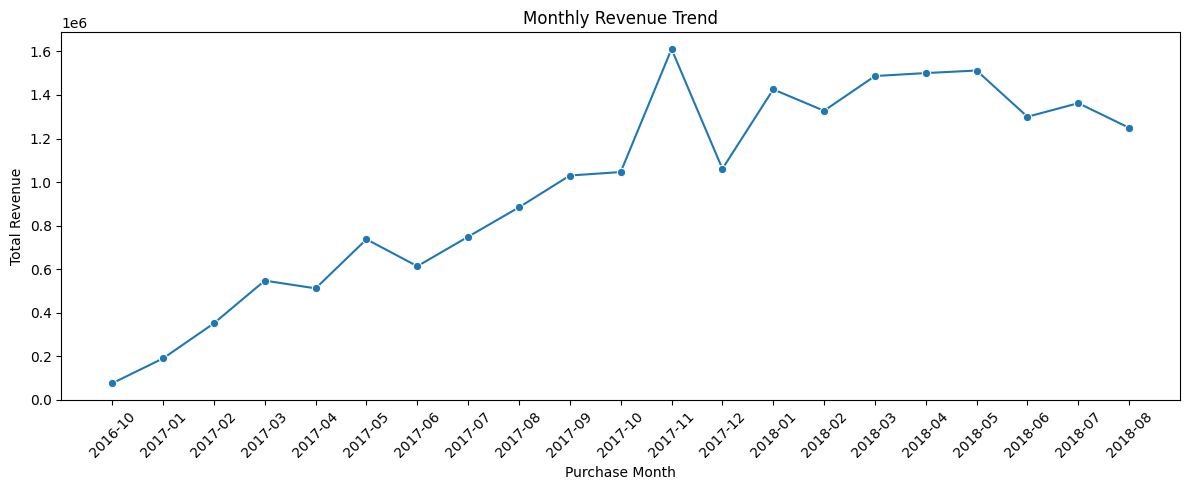

In [11]:
# Visualize monthly revenue trend

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_revenue,
    x="purchase_month",
    y="total_revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Purchase Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

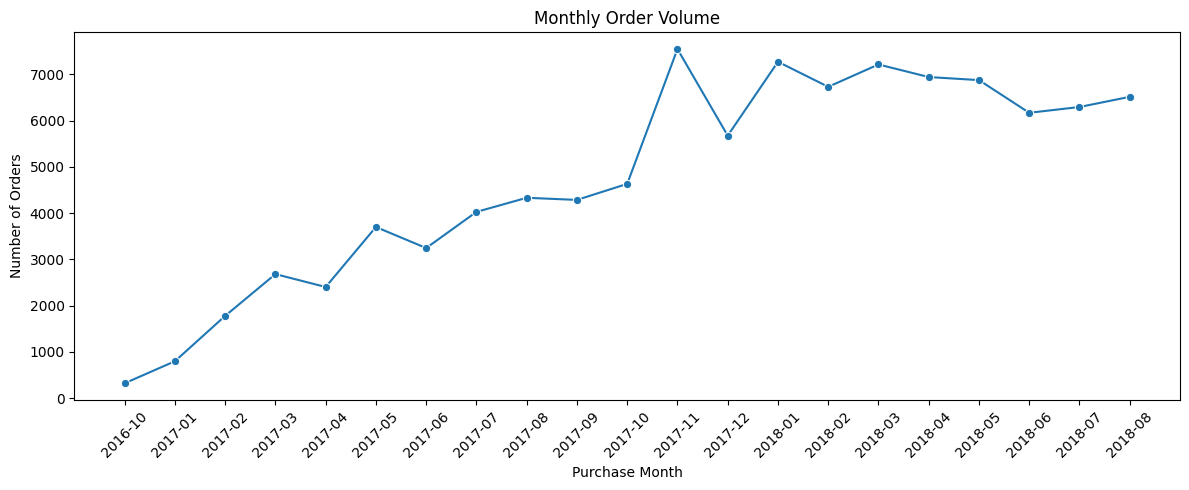

In [12]:
# Visualize monthly order volume

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_revenue,
    x="purchase_month",
    y="number_of_orders",
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Purchase Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

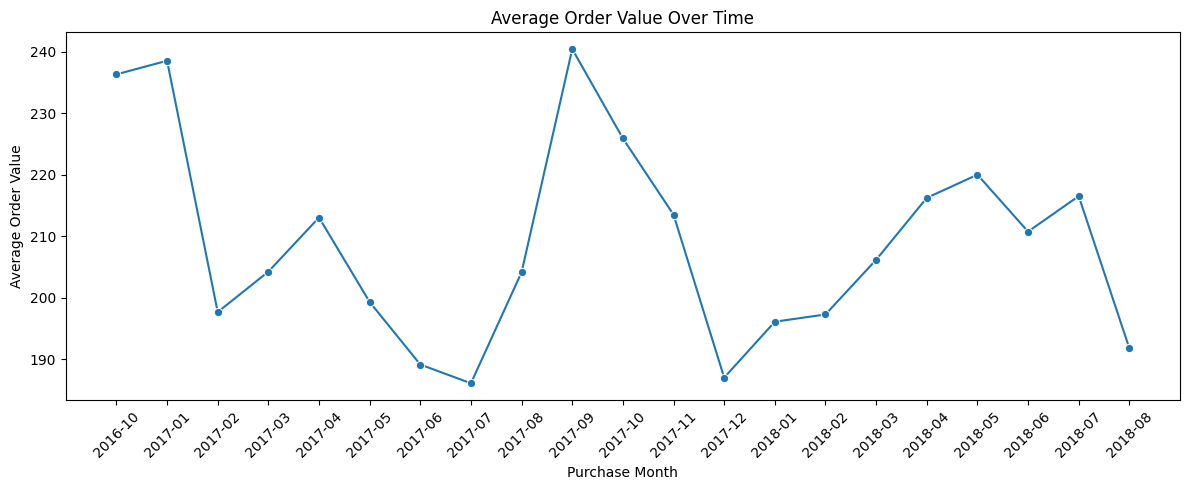

In [13]:
# Visualize average order value over time

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_revenue,
    x="purchase_month",
    y="average_order_value",
    marker="o"
)

plt.title("Average Order Value Over Time")
plt.xlabel("Purchase Month")
plt.ylabel("Average Order Value")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [14]:
# Summary statistics for monthly revenue metrics

monthly_revenue[
    ["total_revenue", "number_of_orders", "average_order_value"]
].describe().round(2)

,total_revenue,number_of_orders,average_order_value
count,21.00,21.00,21.00
mean,979725.08,4734.10,209.05
std,466694.13,2234.36,16.48
min,76559.05,324.00,186.10
25%,613777.41,3245.00,197.29
50%,1046083.41,4631.00,206.17
75%,1362267.08,6728.00,216.51
max,1610581.21,7544.00,240.41


## Monthly Revenue Summary

The monthly revenue analysis reveals strong business growth throughout the observation period. Revenue increased steadily during 2017 before stabilizing at a higher level throughout much of 2018, reaching a peak monthly revenue of approximately **1.61 million**. The sharp decline observed during the final months of the dataset is likely due to incomplete data collection rather than an actual decline in business performance.

Monthly order volume follows almost the same trend as revenue, increasing from fewer than **1,000 orders** per month in the early stages of the dataset to more than **7,500 orders** at its peak. This close relationship suggests that revenue growth was primarily driven by an increasing number of customer orders rather than substantial changes in customer spending.

Average order value remained relatively stable throughout the analysis period, averaging approximately **197** per order. Excluding the first and last few months, which contain limited observations, customer spending generally fluctuated between **190** and **220** per order. This consistency indicates that purchasing behavior remained stable while the business expanded its customer base.

Overall, the results indicate sustained business growth over the observed period, driven largely by increasing transaction volume while maintaining consistent customer spending patterns.

### Part 2 - Product Performance

Understanding product performance is essential for identifying the categories that drive revenue and customer demand. In this section, we compare product categories based on revenue, order volume, and average order value to identify high-performing and high-potential categories.

In [15]:
# Calculate revenue and sales metrics by product category

category_performance = (
    df.groupby("product_category_name")
    .agg(
        total_revenue=("payment_value", "sum"),
        number_of_orders=("order_id", "nunique"),
        average_order_value=("payment_value", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)

category_performance.head()

,product_category_name,total_revenue,number_of_orders,average_order_value
0,cama_mesa_banho,1743998.80,9417,145.478712
1,beleza_saude,1662963.59,8836,165.815494
2,informatica_acessorios,1599481.06,6689,196.255345
3,moveis_decoracao,1443963.61,6449,163.492257
4,relogios_presentes,1430553.48,5624,230.251647


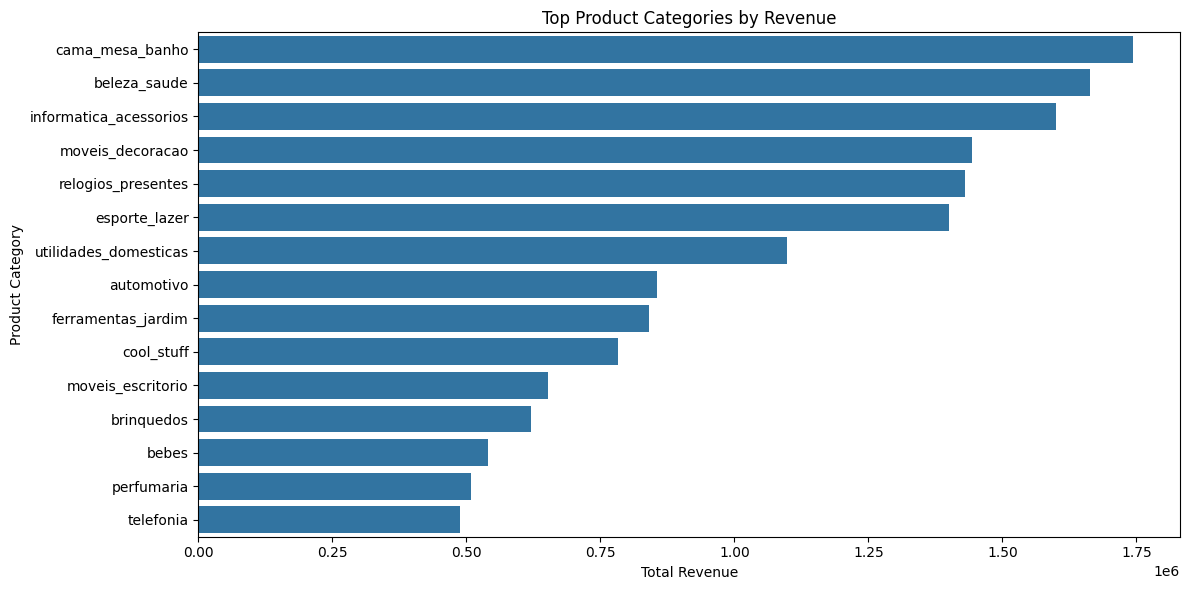

In [16]:
# Top 15 product categories by total revenue

plt.figure(figsize=(12,6))

sns.barplot(
    data=category_performance.head(15),
    x="total_revenue",
    y="product_category_name"
)

plt.title("Top Product Categories by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")

plt.tight_layout()

plt.show()

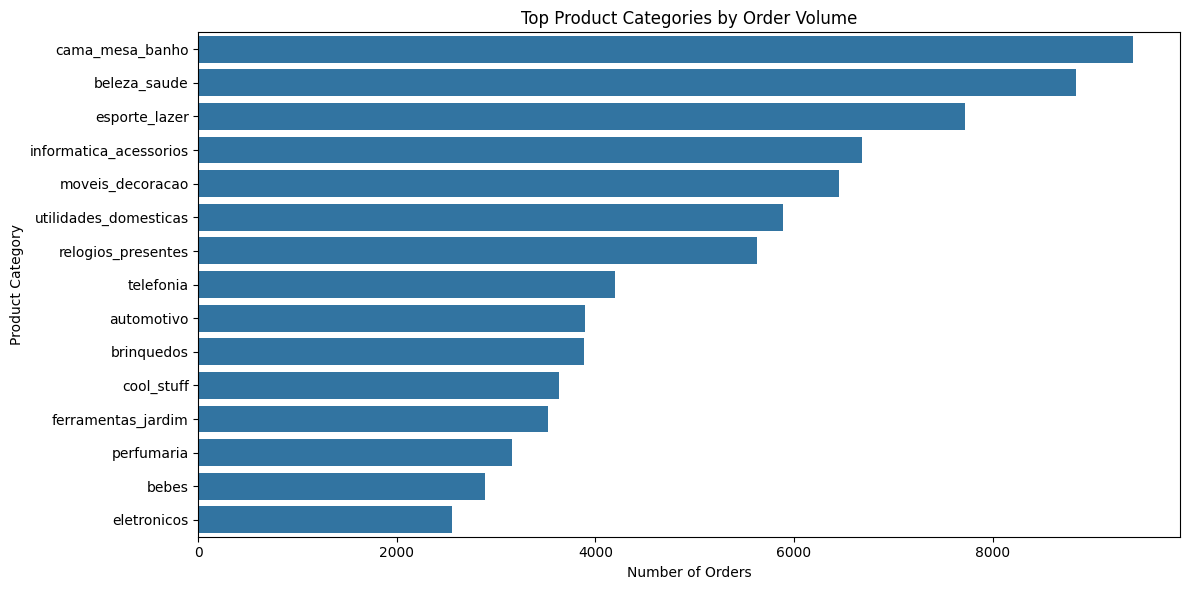

In [17]:
# Top categories by number of orders

top_orders = (
    category_performance
    .sort_values("number_of_orders", ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_orders,
    x="number_of_orders",
    y="product_category_name"
)

plt.title("Top Product Categories by Order Volume")
plt.xlabel("Number of Orders")
plt.ylabel("Product Category")

plt.tight_layout()

plt.show()

In [18]:
# Highest average order value
# Consider only categories with at least 100 orders

high_value_categories = (
    category_performance
    .query("number_of_orders >= 100")
    .sort_values("average_order_value", ascending=False)
)

high_value_categories.head(15)

,product_category_name,total_revenue,number_of_orders,average_order_value
17,pcs,279121.55,181,1268.734318
23,telefonia_fixa,207071.05,217,761.290625
29,agro_industria_e_comercio,118730.61,182,471.153214
28,eletrodomesticos_2,124865.92,234,462.466370
10,moveis_escritorio,652016.50,1273,364.662472
36,sinalizacao_e_seguranca,68488.05,140,340.736567
37,construcao_ferramentas_seguranca,65691.03,167,330.105678
20,instrumentos_musicais,233201.70,628,324.341725
21,eletroportateis,226651.74,630,321.491830
31,climatizacao,91170.66,253,301.889603


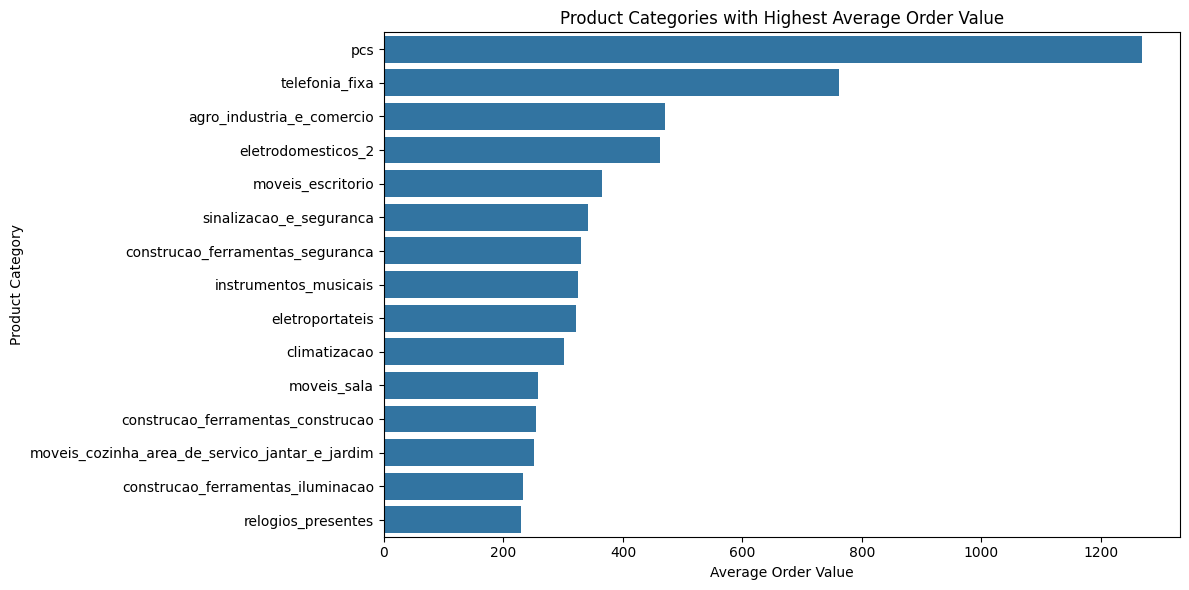

In [19]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=high_value_categories.head(15),
    x="average_order_value",
    y="product_category_name"
)

plt.title("Product Categories with Highest Average Order Value")
plt.xlabel("Average Order Value")
plt.ylabel("Product Category")

plt.tight_layout()

plt.show()

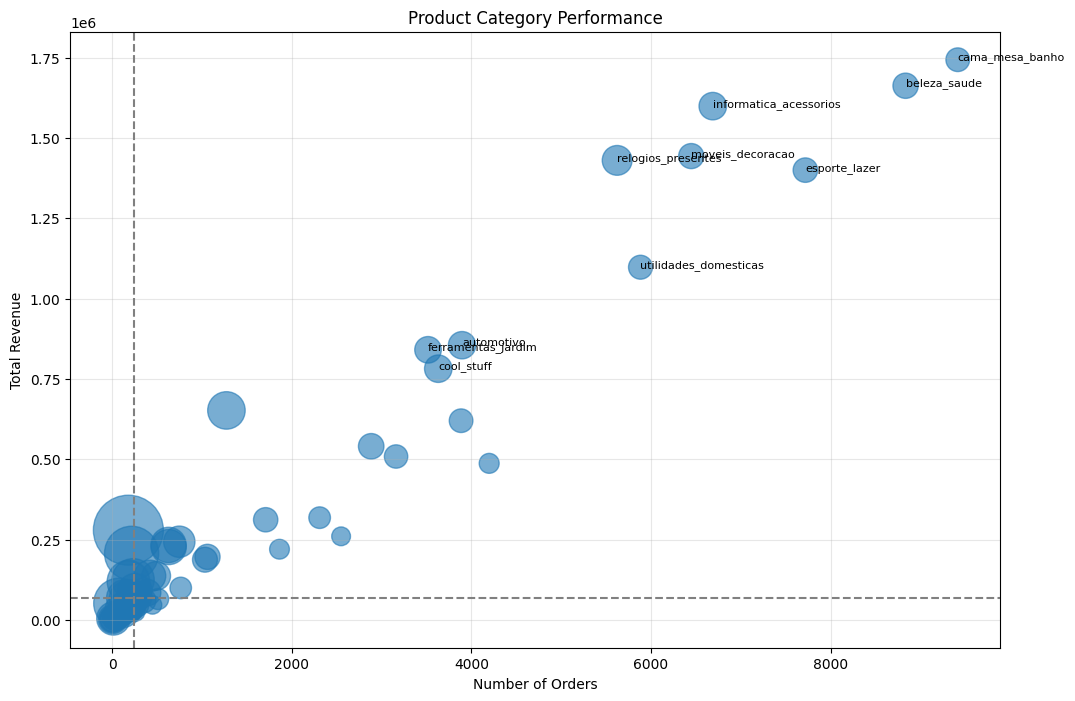

In [25]:
# Bubble chart comparing revenue, order volume, and average order value

plt.figure(figsize=(12,8))

plt.scatter(
    category_performance["number_of_orders"],
    category_performance["total_revenue"],
    s=category_performance["average_order_value"] * 2,
    alpha=0.6
)

# Annotate the top 10 revenue categories
top10 = category_performance.head(10)

for _, row in top10.iterrows():
    plt.text(
        row["number_of_orders"],
        row["total_revenue"],
        row["product_category_name"],
        fontsize=8
    )

plt.title("Product Category Performance")
plt.xlabel("Number of Orders")
plt.ylabel("Total Revenue")

plt.grid(alpha=0.3)

plt.axvline(
    category_performance["number_of_orders"].median(),
    linestyle="--",
    color="gray"
)

plt.axhline(
    category_performance["total_revenue"].median(),
    linestyle="--",
    color="gray"
)

plt.show()

In [24]:
category_performance["revenue_per_order"] = (
    category_performance["total_revenue"]
    / category_performance["number_of_orders"]
)

category_performance.sort_values(
    "revenue_per_order",
    ascending=False
).head(15)

,product_category_name,total_revenue,number_of_orders,average_order_value,revenue_per_order
17,pcs,279121.55,181,1268.734318,1542.108011
23,telefonia_fixa,207071.05,217,761.290625,954.244470
41,portateis_casa_forno_e_cafe,51229.32,75,656.786154,683.057600
29,agro_industria_e_comercio,118730.61,182,471.153214,652.365989
28,eletrodomesticos_2,124865.92,234,462.466370,533.615043
10,moveis_escritorio,652016.50,1273,364.662472,512.188924
36,sinalizacao_e_seguranca,68488.05,140,340.736567,489.200357
37,construcao_ferramentas_seguranca,65691.03,167,330.105678,393.359461
20,instrumentos_musicais,233201.70,628,324.341725,371.340287
31,climatizacao,91170.66,253,301.889603,360.358340


## Product Performance Summary

Product category performance varies considerably across the e-commerce platform, with a small number of categories accounting for a significant share of both revenue and customer demand. Categories such as **Bed, Bath & Table (cama_mesa_banho)**, **Beauty & Health (beleza_saude)**, **Computer Accessories (informatica_acessorios)**, **Furniture Decoration (moveis_decoracao)**, and **Watches & Gifts (relogios_presentes)** generated the highest total revenue, each contributing well over **1 million** in sales.

The highest-revenue categories also ranked among the highest in order volume, indicating that their financial performance is largely driven by strong customer demand. For example, **Bed, Bath & Table** generated approximately **1.74 million** in revenue from more than **9,400 orders**, while **Beauty & Health** generated **1.66 million** from nearly **8,900 orders**. This suggests that these categories serve as core revenue drivers and should remain strategic priorities for inventory planning and marketing investment.

In contrast, several product categories generated relatively modest sales volumes but achieved exceptionally high average order values. Categories such as **PCs**, **Fixed Telephony**, **Agro Industry & Commerce**, and **Office Furniture** recorded some of the highest revenue per order, with average order values ranging from approximately **365** to more than **1,200**. Although these categories contribute fewer transactions, they represent premium product segments where individual purchases generate substantially higher revenue.

The product performance bubble chart highlights these differences by simultaneously comparing order volume, total revenue, and average order value. High-volume categories cluster in the upper-right portion of the chart, representing products that consistently drive business performance, while premium categories appear as larger bubbles with lower order volumes but significantly higher customer spending per transaction. This visualization illustrates that revenue growth can be achieved through two complementary strategies: increasing transaction volume in high-demand categories or expanding sales of premium, high-value products.

Overall, the analysis suggests that the business maintains a well-balanced product portfolio consisting of both high-volume revenue generators and high-value premium categories. Continued investment in top-performing categories, combined with targeted marketing for premium products, could further strengthen revenue growth while diversifying the company's sources of income.